## **Eman Khater**

In [ ]:
# Run this cell to mount your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/My Drive/Dr. Yasser

/content/drive/My Drive/Dr. Yasser


In [ ]:
!ls

1976-2018-house2-unzipped.csv  creditcard_Corre2.csv  creditcard.csv
1976-2018-senate.csv	       creditcard_Corre3.csv  creditcard_Entropy.csv
2012_US_elect_county.csv       creditcard_Corre4.csv  president-1976-2016.csv
Correlation.csv		       creditcard_Corre.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Election_df = pd.read_csv("./president-1976-2016.csv")
Election_df.head()

,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party,writein,candidatevotes,totalvotes,version,notes
0,1976,Alabama,AL,1,63,41,US President,"Carter, Jimmy",democrat,False,659170,1182850,20171015,NaN
1,1976,Alabama,AL,1,63,41,US President,"Ford, Gerald",republican,False,504070,1182850,20171015,NaN
2,1976,Alabama,AL,1,63,41,US President,"Maddox, Lester",american independent party,False,9198,1182850,20171015,NaN
3,1976,Alabama,AL,1,63,41,US President,"Bubar, Benjamin """"Ben""""",prohibition,False,6669,1182850,20171015,NaN
4,1976,Alabama,AL,1,63,41,US President,"Hall, Gus",communist party use,False,1954,1182850,20171015,NaN


In [ ]:
Election_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            3740 non-null   int64  
 1   state           3740 non-null   object 
 2   state_po        3740 non-null   object 
 3   state_fips      3740 non-null   int64  
 4   state_cen       3740 non-null   int64  
 5   state_ic        3740 non-null   int64  
 6   office          3740 non-null   object 
 7   candidate       3474 non-null   object 
 8   party           3404 non-null   object 
 9   writein         3740 non-null   bool   
 10  candidatevotes  3740 non-null   int64  
 11  totalvotes      3740 non-null   int64  
 12  version         3740 non-null   int64  
 13  notes           0 non-null      float64
dtypes: bool(1), float64(1), int64(7), object(5)
memory usage: 383.6+ KB


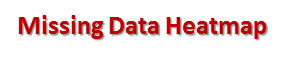

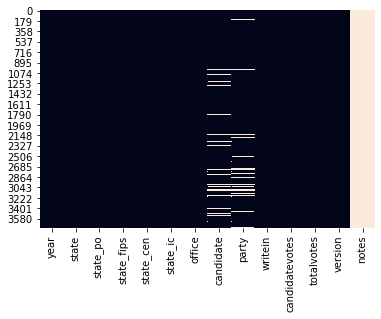

In [ ]:
sns.heatmap(Election_df.isnull(), cbar=False)

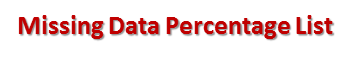

In [ ]:
percent_missing = Election_df.isnull().sum() * 100 / len(Election_df)
missing_value_df = pd.DataFrame({'column_name': Election_df.columns,
                                 'percent_missing': percent_missing})
print(round(missing_value_df ,2))

                   column_name  percent_missing
year                      year             0.00
state                    state             0.00
state_po              state_po             0.00
state_fips          state_fips             0.00
state_cen            state_cen             0.00
state_ic              state_ic             0.00
office                  office             0.00
candidate            candidate             7.11
party                    party             8.98
writein                writein             0.00
candidatevotes  candidatevotes             0.00
totalvotes          totalvotes             0.00
version                version             0.00
notes                    notes           100.00


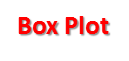

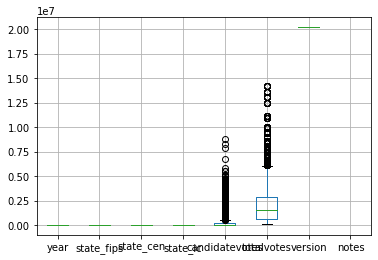

In [ ]:
Election_df.plot.box(grid='True')

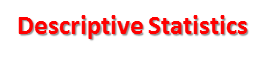

In [ ]:
print( Election_df.describe())

              year   state_fips    state_cen  ...    totalvotes     version  notes
count  3740.000000  3740.000000  3740.000000  ...  3.740000e+03      3740.0    0.0
mean   1996.021390    28.855882    53.874866  ...  2.214284e+06  20171015.0    NaN
std      12.586011    15.637863    26.062865  ...  2.252806e+06         0.0    NaN
min    1976.000000     1.000000    11.000000  ...  1.235740e+05  20171015.0    NaN
25%    1984.000000    17.000000    33.000000  ...  6.296560e+05  20171015.0    NaN
50%    1996.000000    28.000000    54.000000  ...  1.533950e+06  20171015.0    NaN
75%    2008.000000    42.000000    81.000000  ...  2.808605e+06  20171015.0    NaN
max    2016.000000    56.000000    95.000000  ...  1.418160e+07  20171015.0    NaN

[8 rows x 8 columns]


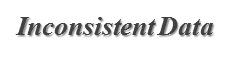

Find Inconsistent Data

In [ ]:
years = Election_df['year'].unique()
years.sort()
years

array([1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016])

In [ ]:
states = Election_df['state'].unique()
states.sort()
states

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

In [ ]:
state_pos = Election_df['state_po'].unique()
state_pos.sort()
state_pos

array(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA',
       'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME',
       'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM',
       'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'], dtype=object)

In [ ]:
state_fipses = Election_df['state_fips'].unique()
state_fipses.sort()
state_fipses

array([ 1,  2,  4,  5,  6,  8,  9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
       38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56])

In [ ]:
state_cens = Election_df['state_cen'].unique()
state_cens.sort()
state_cens

array([11, 12, 13, 14, 15, 16, 21, 22, 23, 31, 32, 33, 34, 35, 41, 42, 43,
       44, 45, 46, 47, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64,
       71, 72, 73, 74, 81, 82, 83, 84, 85, 86, 87, 88, 91, 92, 93, 94, 95])

In [ ]:
state_ics = Election_df['state_ic'].unique()
state_ics.sort()
state_ics

array([ 1,  2,  3,  4,  5,  6, 11, 12, 13, 14, 21, 22, 23, 24, 25, 31, 32,
       33, 34, 35, 36, 37, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52,
       53, 54, 55, 56, 61, 62, 63, 64, 65, 66, 67, 68, 71, 72, 73, 81, 82])

In [ ]:
offices = Election_df['office'].unique()
offices.sort()
offices

array(['US President'], dtype=object)

In [ ]:
candidates = Election_df['candidate'].unique()
candidates

array(['Carter, Jimmy', 'Ford, Gerald', 'Maddox, Lester',
       'Bubar, Benjamin ""Ben""', 'Hall, Gus', 'Macbride, Roger', nan,
       'McCarthy, Eugene ""Gene""', 'Camejo, Peter',
       'Anderson, Thomas J.', 'Wright, Margaret', 'Larouche, Lyndon, Jr.',
       'Scattering', 'Other', 'Julius ""Jules"", Levin', 'Zeidler, Frank',
       'Reagan, Ronald', 'Anderson, John B.', 'Rarick, John',
       'Clark, Edward ""Ed""', 'Deberry, Clifton', 'McReynolds, David',
       'Commoner, Barry', 'Griswold, Deirdre', 'Smith, Maureen',
       'Pulley, Andrew', 'Greaves, Percy L, Jr.', 'Shelton, Frank, Jr.',
       'McCormack, Ellen', 'Lynen, Kurt', 'Gahres, William ""Bill""',
       'Wendelken, Martin E.', 'McLain, Harley', 'Congress, Richard',
       'Mondale, Walter', 'Bergland, David', 'Richards, Bob',
       'Mason, Melvin', 'Serrette, Dennis', 'Johnson, Sonia',
       'Dodge, Earl', 'Lowery, Arthur', 'Dennis, Delmar', 'Holmes, Larry',
       'Winn, Edward', 'Baker, Gerald', 'Bush, George H.W

Edit inconsistent data by :

1 - Convert everything lower case

2 -  Capitalize the first character of a string to capital (uppercase) letter

3 - Remove any white spaces at the beginning and end of cells.

4 - Remove " Charachter

5 - Remove / Charachter

In [ ]:
# convert to lower case
Election_df['candidate'] = Election_df['candidate'].str.lower()
# Capitalize the first character
Election_df['candidate'] = Election_df['candidate'].str.capitalize()
# remove trailing white spaces
Election_df['candidate'] = Election_df['candidate'].str.strip()
# remove " Charachter
Election_df['candidate'] = Election_df['candidate'].str.replace('"', '')
# remove / Charachter
Election_df['candidate'] = Election_df['candidate'].str.replace('/', ' ')

In [ ]:
candidates = Election_df['candidate'].unique()
candidates

array(['Carter, jimmy', 'Ford, gerald', 'Maddox, lester',
       'Bubar, benjamin ben', 'Hall, gus', 'Macbride, roger', nan,
       'Mccarthy, eugene gene', 'Camejo, peter', 'Anderson, thomas j.',
       'Wright, margaret', 'Larouche, lyndon, jr.', 'Scattering', 'Other',
       'Julius jules, levin', 'Zeidler, frank', 'Reagan, ronald',
       'Anderson, john b.', 'Rarick, john', 'Clark, edward ed',
       'Deberry, clifton', 'Mcreynolds, david', 'Commoner, barry',
       'Griswold, deirdre', 'Smith, maureen', 'Pulley, andrew',
       'Greaves, percy l, jr.', 'Shelton, frank, jr.', 'Mccormack, ellen',
       'Lynen, kurt', 'Gahres, william bill', 'Wendelken, martin e.',
       'Mclain, harley', 'Congress, richard', 'Mondale, walter',
       'Bergland, david', 'Richards, bob', 'Mason, melvin',
       'Serrette, dennis', 'Johnson, sonia', 'Dodge, earl',
       'Lowery, arthur', 'Dennis, delmar', 'Holmes, larry',
       'Winn, edward', 'Baker, gerald', 'Bush, george h.w.',
       'Dukakis,

In [ ]:
parties = Election_df['party'].unique()
parties

array(['democrat', 'republican', 'american independent party',
       'prohibition', 'communist party use', 'libertarian', nan,
       'independent', 'socialist workers', 'american', 'peace & freedom',
       'u.s. labor', 'no party affiliation', 'socialist labor',
       'american party of iowa', 'socialist u.s.a.', 'conservative',
       'human rights', "mccarthy '76", "people's",
       'international development bank', 'industrial government party',
       'socialist', 'liberal party', 'free libertarian', 'labor',
       'constitution party', 'concerned citizens', 'statesman',
       'citizens', 'workers world', 'national unity campaign',
       'anderson coalition', 'nominated by petition', 'respect for life',
       'right-to-life', 'middle class candidate', 'down with lawyers',
       "natural people's league", 'populist', 'alliance',
       'united sovereign citizens', 'workers league', 'big deal party',
       'national unity', 'new alliance', 'national economic recovery',
   

In [ ]:
# convert to lower case
Election_df['party'] = Election_df['party'].str.lower()
# Capitalize the first character
Election_df['party'] = Election_df['party'].str.capitalize()
# remove trailing white spaces
Election_df['party'] = Election_df['party'].str.strip()
# remove " Charachter
Election_df['party'] = Election_df['party'].str.replace('"', '')
# remove / Charachter
Election_df['party'] = Election_df['party'].str.replace('/', ' ')

In [ ]:
parties = Election_df['party'].unique()
parties

array(['Democrat', 'Republican', 'American independent party',
       'Prohibition', 'Communist party use', 'Libertarian', nan,
       'Independent', 'Socialist workers', 'American', 'Peace & freedom',
       'U.s. labor', 'No party affiliation', 'Socialist labor',
       'American party of iowa', 'Socialist u.s.a.', 'Conservative',
       'Human rights', "Mccarthy '76", "People's",
       'International development bank', 'Industrial government party',
       'Socialist', 'Liberal party', 'Free libertarian', 'Labor',
       'Constitution party', 'Concerned citizens', 'Statesman',
       'Citizens', 'Workers world', 'National unity campaign',
       'Anderson coalition', 'Nominated by petition', 'Respect for life',
       'Right-to-life', 'Middle class candidate', 'Down with lawyers',
       "Natural people's league", 'Populist', 'Alliance',
       'United sovereign citizens', 'Workers league', 'Big deal party',
       'National unity', 'New alliance', 'National economic recovery',
   

In [ ]:
writeins = Election_df['writein'].unique()
writeins.sort()
writeins

array([False,  True])

In [ ]:
candidatevotes1 = Election_df['candidatevotes'].unique()
candidatevotes1.sort()
candidatevotes1

array([      1,       2,       4, ..., 7854285, 8274473, 8753788])

In [ ]:
totalvotes1 = Election_df['totalvotes'].unique()
totalvotes1.sort()
totalvotes1

array([  123574,   156343,   158445,   168830,   173889,   176551,
         176713,   183902,   185726,   188968,   192877,   199884,
         200116,   201876,   201894,   207605,   211288,   211571,
         213299,   213726,   227572,   227586,   234561,   235642,
         235668,   241620,   243328,   243692,   243861,   249891,
         250701,   254572,   254904,   258449,   258506,   258788,
         265853,   266411,   270810,   282717,   285560,   288256,
         289620,   289701,   291301,   293764,   294308,   297261,
         297308,   299290,   300495,   300678,   301116,   303287,
         308133,   308971,   312309,   312575,   312598,   312833,
         312991,   316269,   316621,   317867,   318608,   320467,
         322932,   323826,   325046,   326197,   327529,   327703,
         328734,   335846,   336254,   339627,   340932,   343133,
         344360,   354461,   360120,   363815,   363952,   365674,
         367951,   370093,   372842,   375190,   381975,   383

In [ ]:
versions = Election_df['version'].unique()
versions.sort()
versions

array([20171015])

# **Find Outliers**

In [ ]:
Q1 = Election_df.quantile(0.25)
Q3 = Election_df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

year                   24.00
state_fips             25.00
state_cen              48.00
state_ic               39.00
writein                 0.00
candidatevotes     223006.25
totalvotes        2178949.00
version                 0.00
notes                    NaN
dtype: float64


In [ ]:
print(Election_df['candidatevotes'].skew())
Election_df['candidatevotes'].describe()

4.11622466847069


count    3.740000e+03
mean     3.151389e+05
std      7.371322e+05
min      1.000000e+00
25%      1.498750e+03
50%      8.992000e+03
75%      2.245050e+05
max      8.753788e+06
Name: candidatevotes, dtype: float64

# **Outliers Visualization**

The skewness value of 4.1 shows that the variable 'candidatevotes' has a right-skewed distribution

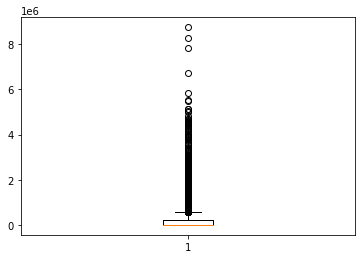

In [ ]:
plt.boxplot(Election_df["candidatevotes"])
plt.show()

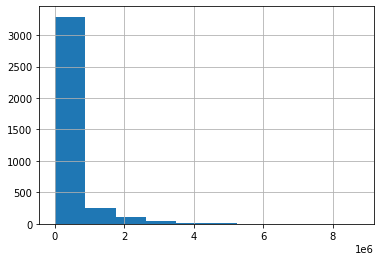

In [ ]:
Election_df.candidatevotes.hist()